In [ ]:
!nvidia-smi

Mon Aug 31 06:10:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -U roboflow python-dotenv

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="eTyMRYo8Xu97aYwwR7Me")

project = rf.workspace("augmented-startups").project("weeds-nxe1w")
version = project.version(3)

dataset = version.download("yolov5")

print(dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Weeds-3 in yolov5pytorch:: 100%|██████████| 8418/8418 [00:01<00:00, 4414.41it/s]


/content/Weeds-3


In [ ]:
!ls -la "{dataset.location}"

ls: cannot access '{dataset.location}': No such file or directory


In [ ]:
!cat "{dataset.location}/data.yaml"

names:
- Weeds
nc: 1
roboflow:
  license: CC BY 4.0
  project: weeds-nxe1w
  url: https://universe.roboflow.com/augmented-startups/weeds-nxe1w/dataset/3
  version: 3
  workspace: augmented-startups
test: ../test/images
train: Weeds-3/train/images
val: Weeds-3/valid/images


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/weed-agricultural-rover"

os.makedirs(PROJECT_DIR, exist_ok=True)

print(PROJECT_DIR)

/content/drive/MyDrive/weed-agricultural-rover


In [ ]:
!ls -la /content

total 20
drwxr-xr-x 1 root root 4096 Aug 31 12:28 .
drwxr-xr-x 1 root root 4096 Aug 31 12:24 ..
drwxr-xr-x 4 root root 4096 Aug 24 13:27 .config
drwx------ 5 root root 4096 Aug 31 12:28 drive
drwxr-xr-x 1 root root 4096 Aug 24 13:28 sample_data


In [ ]:
DATASET_DIR = "/content/drive/MyDrive/weed-agricultural-rover/Weeds-3"

yaml_content = """names:
- Weeds
nc: 1

roboflow:
  license: CC BY 4.0
  project: weeds-nxe1w
  url: https://universe.roboflow.com/augmented-startups/weeds-nxe1w/dataset/3
  version: 3
  workspace: augmented-startups

train: train/images
val: valid/images
test: test/images
"""

with open(f"{DATASET_DIR}/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml updated.")

data.yaml updated.


In [ ]:
%cd /content/drive/MyDrive/weed-agricultural-rover/yolov5

!pip install -q -r requirements.txt

/content/drive/MyDrive/weed-agricultural-rover/yolov5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 6.3 MB/s eta 0:00:00


In [ ]:
import os
import glob

DATASET_DIR = "/content/drive/MyDrive/weed-agricultural-rover/Weeds-3"

train_images = glob.glob(f"{DATASET_DIR}/train/images/*")
valid_images = glob.glob(f"{DATASET_DIR}/valid/images/*")
test_images = glob.glob(f"{DATASET_DIR}/test/images/*")

print("Train images :", len(train_images))
print("Valid images :", len(valid_images))
print("Test images  :", len(test_images))

Train images : 3664
Valid images : 359
Test images  : 180


In [ ]:
train_labels = glob.glob(f"{DATASET_DIR}/train/labels/*")
valid_labels = glob.glob(f"{DATASET_DIR}/valid/labels/*")
test_labels = glob.glob(f"{DATASET_DIR}/test/labels/*")

print("Train labels :", len(train_labels))
print("Valid labels :", len(valid_labels))
print("Test labels  :", len(test_labels))

Train labels : 3664
Valid labels : 359
Test labels  : 180


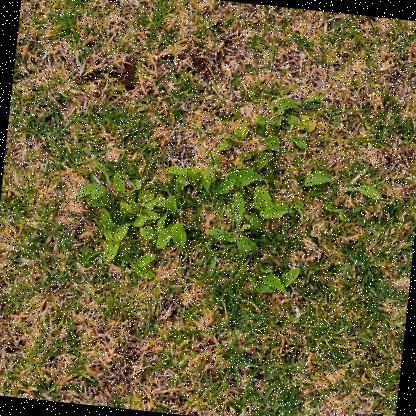

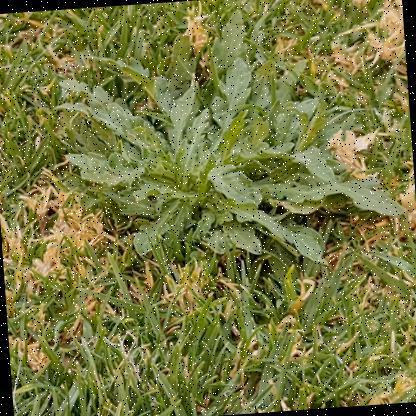

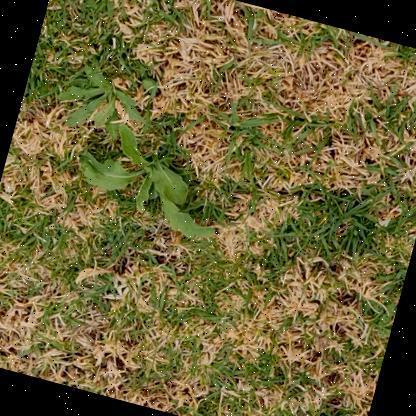

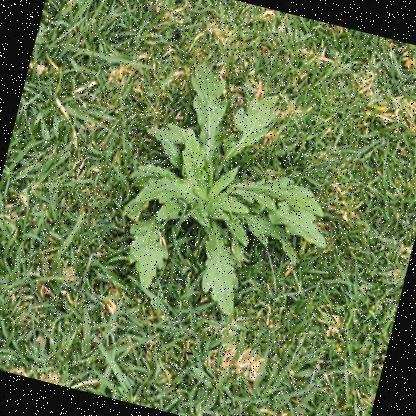

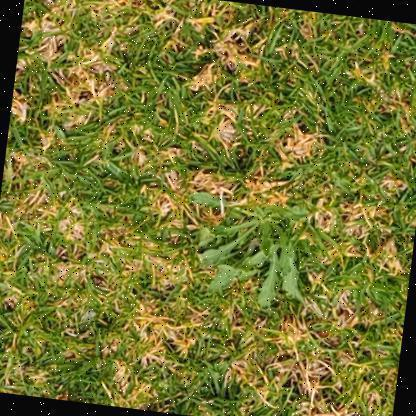

In [ ]:
from IPython.display import Image, display
import random

for img in random.sample(train_images, min(5, len(train_images))):
    display(Image(filename=img, width=500))

In [ ]:
DATASET_DIR = "/content/drive/MyDrive/weed-agricultural-rover/Weeds-3"

yaml_content = f"""train: {DATASET_DIR}/train/images
val: {DATASET_DIR}/valid/images
test: {DATASET_DIR}/test/images

nc: 1
names:
  - Weeds
"""

with open(f"{DATASET_DIR}/data.yaml", "w") as f:
    f.write(yaml_content)

print(yaml_content)

train: /content/drive/MyDrive/weed-agricultural-rover/Weeds-3/train/images
val: /content/drive/MyDrive/weed-agricultural-rover/Weeds-3/valid/images
test: /content/drive/MyDrive/weed-agricultural-rover/Weeds-3/test/images

nc: 1
names:
  - Weeds



In [ ]:
%cd /content/drive/MyDrive/weed-agricultural-rover/yolov5
!pip install roboflow ultralytics opencv-python pytorch

!python train.py \
    --img 640 \
    --batch 16 \
    --epochs 100 \
    --data "/content/drive/MyDrive/weed-agricultural-rover/Weeds-3/data.yaml" \
    --weights yolov5s.pt \
    --name agricultural_rover_weeds \
    --project "/content/drive/MyDrive/weed-agricultural-rover/training" \
    --patience 20

/content/drive/MyDrive/weed-agricultural-rover/yolov5
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pytorch
  Running setup.py clean for pytorch
Failed to build pytorch
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pytorch)
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
WARNING ⚠️ wandb: wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations